In [1]:
import sqlite3
from pathlib import Path

import pandas as pd

# FPA-FOD wildfire records (Short, 6th Edition), 1992-2020, 2.3M rows.
# Feasibility question: can this data answer "which causes dominate across
# contrasting region-seasons, and do the patterns differ?"
# We sample rather than load all 2.3M rows. The sample is SEEDED so every run
# (and every figure) is reproducible: SQLite's RANDOM() is unseeded, so we order
# by a deterministic hash of FOD_ID salted with SEED instead. This matches the
# sampling in src/season_maps.py, so the analysis cells and the talk visuals are
# built from the same 400K draw.
DB_PATH = Path("../data/FPA_FOD_20221014.sqlite")

COLUMNS = [
    "FOD_ID",
    "FIRE_YEAR",
    "DISCOVERY_DOY",
    "NWCG_GENERAL_CAUSE",
    "STATE",
    "LATITUDE",
    "LONGITUDE",
    "FIRE_SIZE",
]

SAMPLE_SIZE = 400_000
SEED = 696

with sqlite3.connect(DB_PATH) as conn:
    fires = pd.read_sql_query(
        f"SELECT {', '.join(COLUMNS)} FROM Fires "
        f"ORDER BY substr(FOD_ID * 2654435761 + {SEED}, -8) "
        f"LIMIT {SAMPLE_SIZE}",
        conn,
    )

print(f"Sampled {len(fires):,} of 2,303,566 rows (seed {SEED})")
fires.head()

Sampled 400,000 of 2,303,566 rows (seed 696)


,FOD_ID,FIRE_YEAR,DISCOVERY_DOY,NWCG_GENERAL_CAUSE,STATE,LATITUDE,LONGITUDE,FIRE_SIZE
0,39283,2009,226,Recreation and ceremony,CO,39.680833,-106.396111,0.1
1,400039283,2016,200,Power generation/transmission/distribution,CA,33.900526,-117.403733,1.0
2,19504421,2010,58,Missing data/not specified/undetermined,NC,34.213333,-78.721667,1.0
3,201607785,2012,293,Missing data/not specified/undetermined,SD,44.064800,-103.409200,1.1
4,501977,2007,120,Debris and open burning,ID,48.711660,-116.328000,0.1


## Data Provenance

Datasets retrieved for this project, with source of record.

### 1. Wildfire records — FPA-FOD (primary dataset)
- **What:** Fire Program Analysis fire-occurrence database, 6th Edition —
  spatial wildfire occurrence for the U.S., **1992–2020**, 2,303,566 records
  with cause, location (lat/lon, state, county/FIPS), discovery date, and size.
- **File:** `data/FPA_FOD_20221014.sqlite` (SpatiaLite; ~914 MB).
  Analysis uses the `Fires` table.
- **Retrieved from:** Kaggle mirror — "2.3 Million U.S. Wildfires" (Brad Darrow).
  https://www.kaggle.com/datasets/braddarrow/23-million-wildfires
  This is a re-host of the USDA dataset below; the original archive is the
  authoritative source of record.
- **Original source:** Short, K. C. (2022). *Spatial wildfire occurrence data
  for the United States, 1992-2020 [FPA_FOD_20221014]* (6th ed.). Fort Collins,
  CO: USDA Forest Service Research Data Archive.
  https://doi.org/10.2737/RDS-2013-0009.6
- **Terms:** U.S. Government public-domain data; free to use with attribution.

### 2. Ecoregion boundaries — EPA Level III (spatial join layer)
- **What:** Omernik Level III ecoregion polygons for the continental U.S.,
  split by state boundary (`STATE_NAME` attribute), used as the region unit
  for cause analysis. **CONUS only** — excludes AK and HI.
- **File:** `data/us_eco_l3_state_boundaries.zip` (~35 MB; retrieved
  2026-07-07). CRS: USA Contiguous Albers Equal Area Conic.
- **Source:** U.S. Environmental Protection Agency. *Level III and IV
  Ecoregions of the Continental United States.*
  https://www.epa.gov/eco-research/level-iii-and-iv-ecoregions-continental-united-states
- **Terms:** U.S. Government public-domain data.


## Known Biases & Limitations

FPA-FOD is not a purpose-built survey. It is a **harvest and reconciliation** of
records from dozens of pre-existing federal, state, and local reporting systems
(USFS FIRESTAT, DOI WFMI, FWS, National Association of State Foresters, NFIRS,
IRWIN, direct submissions from 33 states + PR, and ICS-209 for large fires),
deduplicated and mapped onto NWCG standards by Short (2022). A record was
included only if it had a discovery date, a final size, and a location precise
to ~1 sq mi (PLSS section). **It therefore reflects what agencies chose to
report and how well they reported it — not a uniform sample of fires on the
ground.** The biases below bear directly on the cause × region × season question.

1. **Non-random missing cause (the central variable).** ~26% of records are
   "Missing/not specified/undetermined." Cause determination depends on
   investigation capacity, which varies by agency, state, and era — so the
   missing share is *not* uniform across regions or seasons. Dropping these
   records (as this analysis does) removes a non-random subset, which can shift
   the apparent dominant cause of a given region-season. **This is the bias most
   likely to distort the findings** and is tested in the diagnostic below.

2. **Non-federal completeness varies by state and year.** The source metadata
   warns that "viable state and local records were not available from all states
   for all years... [estimates] may underrepresent actual wildfire activity in
   certain areas and time periods." Region is thus confounded with reporting
   completeness: a low count in an ecoregion may mean few fires *or* poor
   reporting.

3. **Federal vs. non-federal skews the cause mix geographically.** Federal
   records (heavy in the West) are more complete and consistent than state/local
   records (dominant in the Southeast). The West-lightning vs. Southeast-debris
   contrast is partly real fire ecology and partly a difference in who reports
   and how — the *direction* is physically expected, but the *magnitude* is
   entangled with reporting regime.

4. **Detection favors large and human-proximate fires.** Small, remote fires are
   under-recorded; the metadata notes area burned is more reliable than fire
   *counts* for this reason. This tilts the record toward human-cause fires near
   population and roads.

5. **Cause standard changed mid-record.** The NWCG cause standard was updated
   (approved Aug 2020) and older records were remapped "when possible," so cause
   definitions are not perfectly stable across the 1992–2020 span — a concern
   only for cross-year comparisons.

**Implication for this analysis.** Findings are reported as **cause composition
(shares), not counts**, which is robust to completeness bias (2, 4). The
*direction* of the region and season signals is reliable; the *exact
percentages* are not, and should be read as "strongly different," not as precise
estimates. Bias (1) is directly testable and is checked next.

> **Diagnostic result (bias 1, from the cell below).** Missing-cause rate is
> **flat across seasons** (23.5%–26.0%, a 2.5-pt spread) — so the seasonal
> composition finding is *not* a reporting artifact and stands on its own. But
> it is **strongly differential across ecoregions** (3.7% to 66.4%, a 62.6-pt
> spread). Critically, the lowest-missing regions are the high-Natural federal
> West (Idaho Batholith 3.7%, Blue Mountains 4.5%) and the highest-missing are
> the human-ignition Southwest/Plains (Sonoran Basin and Range 66.4%,
> Southwestern Tablelands 59.4%). This is bias (3) made quantitative: the
> spatial Natural-share contrast is real in **direction** but **amplified in
> magnitude** by the fact that low-Natural regions also drop the most records.
> The regional comparison is therefore reported directionally, with this
> differential missingness noted; the seasonal comparison needs no such caveat.

In [2]:
# Can the data answer the question? Check the three dimensions it depends on.

# 1. Are the key columns populated? (null / "Missing" share)
print("--- Missingness ---")
null_share = fires.isna().mean()
missing_cause = fires["NWCG_GENERAL_CAUSE"].str.startswith("Missing").mean()
print(null_share[null_share > 0].round(4).to_string() or "no nulls in key cols")
print(f"cause = 'Missing/undetermined': {missing_cause:.1%}")

# 2. Does CAUSE vary? (the thing we're comparing)
print("\n--- Cause distribution (usable = non-Missing) ---")
usable = fires[~fires["NWCG_GENERAL_CAUSE"].str.startswith("Missing")]
print(usable["NWCG_GENERAL_CAUSE"].value_counts())

# 3. Do REGION and SEASON give enough cells to contrast?
fires["month"] = ((fires["DISCOVERY_DOY"] - 1) // 30 + 1).clip(upper=12)
print(f"\nStates represented: {fires['STATE'].nunique()}")
print(f"Years: {fires['FIRE_YEAR'].min()}-{fires['FIRE_YEAR'].max()}")

# smallest unit we'd actually compare: state x season-month x cause
season = pd.cut(fires["DISCOVERY_DOY"], [0, 79, 171, 264, 366],
                labels=["Winter", "Spring", "Summer", "Fall"])
cells = usable.assign(season=season.loc[usable.index]).groupby(
    ["STATE", "season", "NWCG_GENERAL_CAUSE"], observed=True).size()
print(f"\nNon-empty (state x season x cause) cells: {len(cells):,}")
print(f"Median records per cell: {cells.median():.0f}")


--- Missingness ---
Series([], )
cause = 'Missing/undetermined': 25.9%

--- Cause distribution (usable = non-Missing) ---
NWCG_GENERAL_CAUSE
Debris and open burning                       93256
Natural                                       56915
Arson/incendiarism                            55581
Equipment and vehicle use                     32941
Recreation and ceremony                       17106
Misuse of fire by a minor                     11521
Smoking                                       11154
Railroad operations and maintenance            6423
Power generation/transmission/distribution     5762
Fireworks                                      3233
Other causes                                   1865
Firearms and explosives use                     484
Name: count, dtype: int64

States represented: 52
Years: 1992-2020

Non-empty (state x season x cause) cells: 2,008
Median records per cell: 22


In [3]:
# Seasonality first look: does cause composition actually shift across seasons?
# If it doesn't, the "season" half of the research question has nothing to stand on.

# Meteorological seasons keyed off discovery day-of-year.
# Dec-Feb Winter, Mar-May Spring, Jun-Aug Summer, Sep-Nov Fall.
# DOY ~ 60=Mar 1, 152=Jun 1, 244=Sep 1, 335=Dec 1 (non-leap approximation).
def to_season(doy):
    if doy >= 335 or doy < 60:
        return "Winter"
    if doy < 152:
        return "Spring"
    if doy < 244:
        return "Summer"
    return "Fall"

usable = fires[~fires["NWCG_GENERAL_CAUSE"].str.startswith("Missing")].copy()
usable["season"] = usable["DISCOVERY_DOY"].map(to_season)

# 1. Are all four seasons represented, with enough volume?
print("--- Fires per season ---")
print(usable["season"].value_counts().reindex(
    ["Winter", "Spring", "Summer", "Fall"]))

# 2. Does the cause MIX shift by season? (row = season, cols = cause share %)
print("\n--- Cause composition by season (% within season) ---")
comp = (
    pd.crosstab(usable["season"], usable["NWCG_GENERAL_CAUSE"],
               normalize="index")
    .reindex(["Winter", "Spring", "Summer", "Fall"])
    .mul(100).round(1)
)
# show the causes that move the most across seasons
spread = (comp.max() - comp.min()).sort_values(ascending=False)
print(comp[spread.index[:6]].to_string())

print("\n--- Biggest seasonal swings (max-min share, pct points) ---")
print(spread.head(6).round(1).to_string())


--- Fires per season ---
season
Winter    44849
Spring    98823
Summer    99667
Fall      52902
Name: count, dtype: int64

--- Cause composition by season (% within season) ---
NWCG_GENERAL_CAUSE  Natural  Debris and open burning  Arson/incendiarism  Recreation and ceremony  Equipment and vehicle use  Fireworks
season                                                                                                                                 
Winter                  1.0                     48.7                24.0                      3.6                        9.4        0.3
Spring                  5.5                     41.8                23.8                      4.8                        9.4        0.3
Summer                 44.4                     13.7                 9.8                      6.4                       12.5        2.6
Fall                   12.8                     31.2                21.8                      8.3                       13.2        0.4

--- Bi

In [4]:
# Spatial feasibility: is there enough cause variation by REGION?
# Region = EPA Level III ecoregion (what the peer-reviewed FPA-FOD cause
# literature uses). Spatial-join fire points to the ecoregion polygons.
# Shapefile is CONUS only -> AK/HI won't match and are handled at state grain.
import geopandas as gpd

ECO_PATH = Path("../data/us_eco_l3_state_boundaries/"
                "us_eco_l3_state_boundaries.shp")

eco = gpd.read_file(ECO_PATH)[
    ["US_L3NAME", "STATE_NAME", "NA_L1NAME", "geometry"]
]

# Fire points -> GeoDataFrame in WGS84, then reproject to the ecoregion CRS.
pts = gpd.GeoDataFrame(
    usable.copy(),
    geometry=gpd.points_from_xy(usable["LONGITUDE"], usable["LATITUDE"]),
    crs="EPSG:4326",
).to_crs(eco.crs)

joined = gpd.sjoin(pts, eco, how="left", predicate="within")

# Match rate = data-quality check (AK/HI + any bad coords fall outside CONUS).
matched = joined["US_L3NAME"].notna()
print(f"Points matched to a CONUS ecoregion: {matched.mean():.1%} "
      f"({matched.sum():,} of {len(joined):,})")
print("Unmatched by state (expected: AK, HI, bad coords):")
print(joined.loc[~matched, "STATE"].value_counts().head())


Points matched to a CONUS ecoregion: 99.2% (293,801 of 296,241)
Unmatched by state (expected: AK, HI, bad coords):
STATE
AK    2178
PR      61
NJ      32
HI      32
CA      29
Name: count, dtype: int64


In [5]:
# Does the CAUSE mix actually differ across ecoregions?
# If dominant cause varies region to region, the spatial half of the
# question holds. Restrict to ecoregions with enough sample to be meaningful.
eco_fires = joined[matched].copy()

MIN_PER_REGION = 100
counts = eco_fires["US_L3NAME"].value_counts()
big = counts[counts >= MIN_PER_REGION].index
sub = eco_fires[eco_fires["US_L3NAME"].isin(big)]
print(f"{len(big)} ecoregions with >= {MIN_PER_REGION} sampled fires")

# Dominant cause per ecoregion, and how much regions disagree.
dominant = (
    sub.groupby("US_L3NAME")["NWCG_GENERAL_CAUSE"]
    .agg(lambda s: s.value_counts().idxmax())
)
print(f"\nDistinct dominant causes across those regions: "
      f"{dominant.nunique()}")
print(dominant.value_counts().to_string())

# Concrete contrast: dominant cause + its share, most-natural vs most-human.
share_natural = (
    sub.assign(is_nat=sub["NWCG_GENERAL_CAUSE"].eq("Natural"))
    .groupby("US_L3NAME")["is_nat"].mean().sort_values()
)
print("\nMost human-ignition ecoregions (lowest Natural share):")
print((share_natural.head(5) * 100).round(1).to_string())
print("\nMost lightning-ignition ecoregions (highest Natural share):")
print((share_natural.tail(5) * 100).round(1).to_string())


84 ecoregions with >= 100 sampled fires

Distinct dominant causes across those regions: 4
NWCG_GENERAL_CAUSE
Debris and open burning      40
Natural                      26
Arson/incendiarism           10
Equipment and vehicle use     8

Most human-ignition ecoregions (lowest Natural share):
US_L3NAME
Lake Agassiz Plain                  0.7
Central Appalachians                0.7
Interior River Valleys and Hills    0.7
Western Allegheny Plateau           0.8
Central California Valley           0.9

Most lightning-ignition ecoregions (highest Natural share):
US_L3NAME
Central Basin and Range         71.8
Arizona/New Mexico Mountains    72.0
Northern Basin and Range        74.3
Colorado Plateaus               80.3
Idaho Batholith                 84.0


In [6]:
# Diagnostic for Bias #1: is the missing-cause rate uniform, or concentrated?
# Reporting cause as *shares* is only robust if the ~26% "Missing" records are
# dropped at roughly the same rate everywhere. If missingness swings hard across
# regions or seasons, a "cause difference" could be a reporting artifact instead.
#
# NB: `joined` was built from `usable`, which already dropped Missing -- so we
# must re-join the FULL sample (`fires`, Missing included) to the ecoregions
# here, or the rate is trivially 0 everywhere.
fires_pts = gpd.GeoDataFrame(
    fires.copy(),
    geometry=gpd.points_from_xy(fires["LONGITUDE"], fires["LATITUDE"]),
    crs="EPSG:4326",
).to_crs(eco.crs)
all_eco = gpd.sjoin(fires_pts, eco, how="left", predicate="within")
all_eco = all_eco[all_eco["US_L3NAME"].notna()].copy()  # CONUS matches only

all_eco["is_missing"] = all_eco["NWCG_GENERAL_CAUSE"].str.startswith("Missing")
all_eco["season"] = all_eco["DISCOVERY_DOY"].map(to_season)

overall = all_eco["is_missing"].mean()
print(f"Overall missing-cause rate (CONUS matched): {overall:.1%}\n")

# By season -- 4 values.
print("--- Missing rate by season ---")
by_season = all_eco.groupby("season")["is_missing"].mean().reindex(
    ["Winter", "Spring", "Summer", "Fall"])
print((by_season * 100).round(1).to_string())
print(f"season spread (max-min): {(by_season.max()-by_season.min())*100:.1f} pts\n")

# By ecoregion -- distribution across regions with adequate sample.
print("--- Missing rate by ecoregion (regions with >= 100 fires) ---")
eco_counts = all_eco["US_L3NAME"].value_counts()
big_eco = eco_counts[eco_counts >= 100].index
by_eco = all_eco[all_eco["US_L3NAME"].isin(big_eco)].groupby(
    "US_L3NAME")["is_missing"].mean()
print(f"regions: {len(by_eco)}   min: {by_eco.min()*100:.1f}%   "
      f"median: {by_eco.median()*100:.1f}%   max: {by_eco.max()*100:.1f}%   "
      f"spread: {(by_eco.max()-by_eco.min())*100:.1f} pts")
print("\nlowest-missing regions:")
print((by_eco.sort_values().head(3) * 100).round(1).to_string())
print("highest-missing regions:")
print((by_eco.sort_values().tail(3) * 100).round(1).to_string())

# The interaction is where it bites hardest -- worst-case ecoregion x season cell.
inter = (all_eco[all_eco["US_L3NAME"].isin(big_eco)]
         .groupby(["US_L3NAME", "season"])["is_missing"].agg(["mean", "size"]))
inter = inter[inter["size"] >= 30]  # only cells we'd actually report on
print(f"\n--- Ecoregion x season cells (>= 30 fires): {len(inter)} ---")
print(f"missing-rate range across cells: {inter['mean'].min()*100:.1f}% "
      f"to {inter['mean'].max()*100:.1f}%")


Overall missing-cause rate (CONUS matched): 25.0%

--- Missing rate by season ---
season
Winter    26.0
Spring    25.4
Summer    23.5
Fall      26.0
season spread (max-min): 2.5 pts

--- Missing rate by ecoregion (regions with >= 100 fires) ---
regions: 85   min: 3.7%   median: 23.1%   max: 66.4%   spread: 62.6 pts

lowest-missing regions:
US_L3NAME
Idaho Batholith    3.7
Blue Mountains     4.5
North Cascades     7.9
highest-missing regions:
US_L3NAME
High Plains                53.4
Southwestern Tablelands    59.4
Sonoran Basin and Range    66.4

--- Ecoregion x season cells (>= 30 fires): 316 ---
missing-rate range across cells: 2.7% to 77.1%


In [7]:
# Feasibility of the IMPACT-WEIGHTING step. The product ranks causes not by how
# often they ignite but by how much they BURN -- expected fire size per cause.
# That extra step only earns its place if three things hold in the data:
#   (a) FIRE_SIZE is present on every record (no missingness to model around),
#   (b) burn is concentrated -- a few fires drive most acres, so weighting by
#       size is not the same as weighting by count, and
#   (c) the cause that IGNITES most differs from the cause that BURNS most,
#       at least in some region-seasons -- otherwise ranking by size is
#       redundant with the count ranking we already have.
# If (c) never happens, impact-weighting adds nothing and should be dropped.

# (a) Completeness: FPA-FOD's inclusion rule requires a final size on every row.
print("--- FIRE_SIZE completeness ---")
print(f"null FIRE_SIZE: {fires['FIRE_SIZE'].isna().mean():.4%}   "
      f"non-positive: {(fires['FIRE_SIZE'] <= 0).mean():.4%}")

# (b) Concentration: what share of total acres comes from the largest fires?
sz = fires["FIRE_SIZE"].sort_values(ascending=False).to_numpy()
tot = sz.sum()
for pct in (0.01, 0.05, 0.10):
    k = max(1, int(len(sz) * pct))
    print(f"top {pct:>4.0%} of fires by size = {sz[:k].sum()/tot:5.1%} of acres burned")

# (c) Count-rank vs burn-rank, WITHIN region-season. Use CONUS-matched, non-Missing
# fires (eco_fires already = joined[matched]); add season.
ew = eco_fires.copy()
ew["season"] = ew["DISCOVERY_DOY"].map(to_season)

# Only cells with enough fires to rank causes on (same >=30 bar as the bias cell).
grp = ew.groupby(["US_L3NAME", "season"])
disagree = 0
total_cells = 0
examples = []
for (region, season), g in grp:
    if len(g) < 30:
        continue
    total_cells += 1
    by_count = g["NWCG_GENERAL_CAUSE"].value_counts()
    by_burn = g.groupby("NWCG_GENERAL_CAUSE")["FIRE_SIZE"].sum().sort_values(ascending=False)
    top_ignite, top_burn = by_count.index[0], by_burn.index[0]
    if top_ignite != top_burn:
        disagree += 1
        examples.append((region, season, top_ignite, top_burn,
                         by_burn.iloc[0] / by_burn.sum()))

print(f"\n--- Ignition-leader vs burn-leader, per region-season (>=30 fires) ---")
print(f"cells evaluated: {total_cells}")
print(f"cells where TOP IGNITER != TOP BURNER: {disagree} "
      f"({disagree/total_cells:.0%})")
print("\nExamples (region | season | most ignitions -> most acres | burn-leader's acre share):")
for region, season, ig, bn, share in sorted(examples, key=lambda x: -x[4])[:6]:
    print(f"  {region[:28]:28} {season:6} | {ig[:22]:22} -> {bn[:22]:22} ({share:.0%})")


--- FIRE_SIZE completeness ---
null FIRE_SIZE: 0.0000%   non-positive: 0.0000%
top   1% of fires by size = 89.3% of acres burned
top   5% of fires by size = 96.2% of acres burned
top  10% of fires by size = 97.9% of acres burned

--- Ignition-leader vs burn-leader, per region-season (>=30 fires) ---
cells evaluated: 310
cells where TOP IGNITER != TOP BURNER: 140 (45%)

Examples (region | season | most ignitions -> most acres | burn-leader's acre share):
  Flint Hills                  Summer | Debris and open burnin -> Natural                (96%)
  Northern Lakes and Forests   Summer | Debris and open burnin -> Natural                (96%)
  Southern California/Northern Winter | Equipment and vehicle  -> Smoking                (95%)
  Northern Minnesota Wetlands  Spring | Debris and open burnin -> Arson/incendiarism     (94%)
  Southern California Mountain Winter | Equipment and vehicle  -> Recreation and ceremon (93%)
  Southern California Mountain Spring | Equipment and vehicle  -> P

## References

Short, Karen C. 2022. Spatial wildfire occurrence data for the United States, 1992-2020 [FPA_FOD_20221014]. 6th Edition. Fort Collins, CO: Forest Service Research Data Archive. https://doi.org/10.2737/RDS-2013-0009.6

The choice of **EPA Level III (Omernik) ecoregions** as the spatial unit for
analyzing wildfire cause follows peer-reviewed practice: ignition cause
(human vs. lightning) tracks ecological and climatic drivers — fuel, terrain,
settlement, and storm patterns — rather than administrative boundaries, so
ecoregions group fires by the mechanisms that actually differentiate cause.

- Syphard, A. D., Keeley, J. E., Conlisk, E., & Gough, M. (2025). Regional
  patterns in U.S. wildfire activity: the critical role of ignition sources.
  *Environmental Research Letters*, 20(5), 054046.
  https://doi.org/10.1088/1748-9326/adc9c8

- Chen, B., & Jin, Y. (2022). Spatial patterns and drivers for wildfire
  ignitions in California. *Environmental Research Letters*, 17(5), 055004.
  https://doi.org/10.1088/1748-9326/ac60da

**Data — ecoregion boundaries:** U.S. Environmental Protection Agency, Level III
and IV Ecoregions of the Continental United States (`us_eco_l3_state_boundaries`).
https://www.epa.gov/eco-research/level-iii-and-iv-ecoregions-continental-united-states


## Practice-talk visuals

Season small-multiple maps of wildfire cause across CONUS EPA Level III
ecoregions, rendered by [`src/season_maps.py`](../src/season_maps.py) and saved
to [`img/`](../img). Three candidate encodings, plus an animated GIF of the hero
map (Natural share by season). Honesty conventions match the feasibility work:
cause read as *shares*; region-seasons under 30 fires left blank; regions with
&ge;40% missing cause hatched, so differential missingness is shown, not hidden.

In [8]:
# Load + spatial-join a larger sample for stable per-region-season cells.
# season_maps lives in ../src; seed fixes the sample so figures are reproducible.
import sys
sys.path.insert(0, "../src")
import season_maps as sm

vis_joined, vis_eco, vis_high_miss = sm.load_joined(sample_size=400_000, seed=696)
print(f"matched fires: {len(vis_joined):,} | high-missing regions (hatched): "
      f"{len(vis_high_miss)}")

matched fires: 391,540 | high-missing regions (hatched): 14


saved img/natural_share_seasons.png
saved img/dominant_count_seasons.png
saved img/dominant_acres_seasons.png


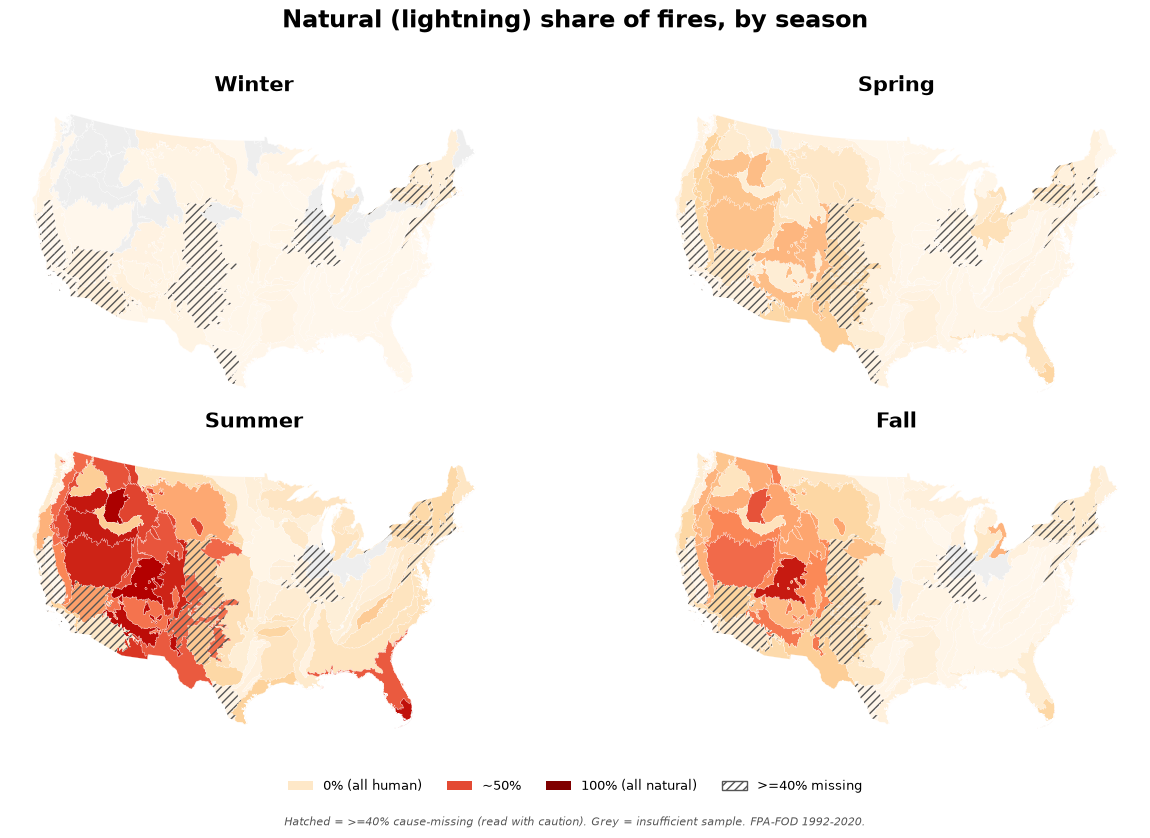

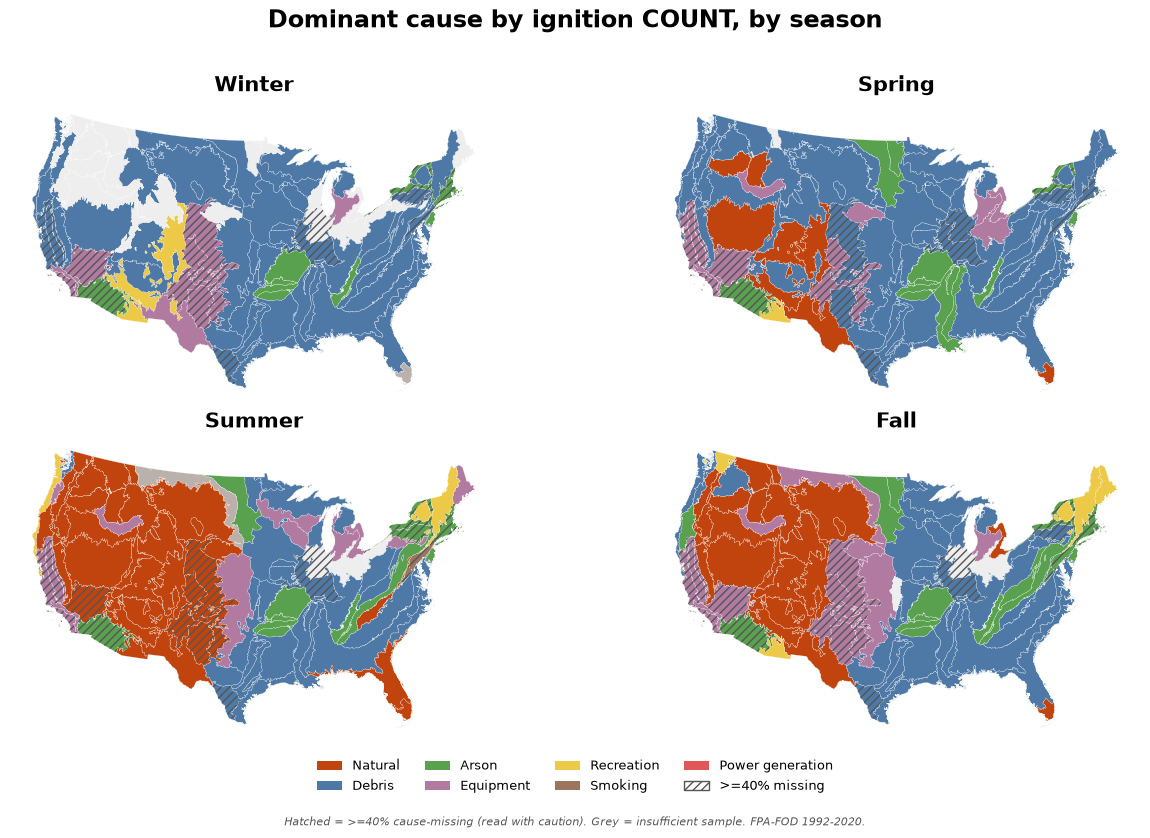

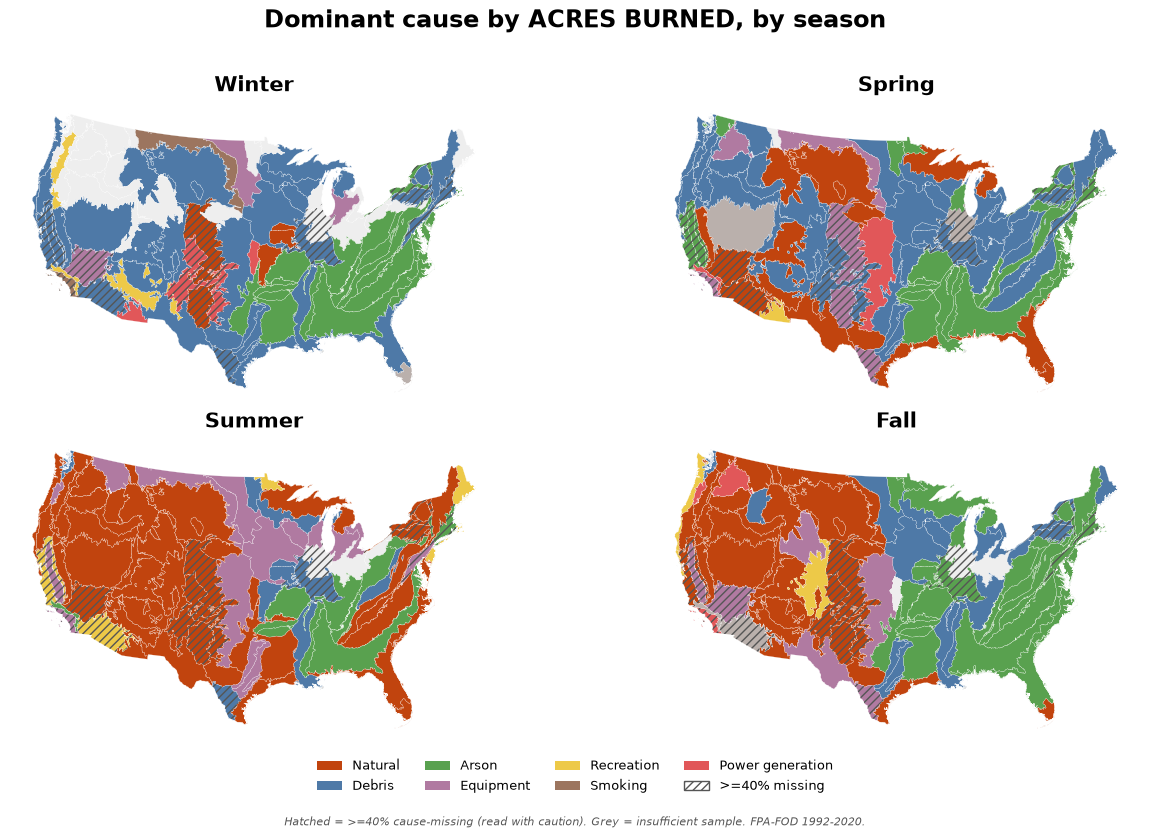

In [9]:
# Render all three candidate encodings inline and to img/*.png.
#   A. natural_share  -- hero: sequential Natural (lightning) share
#   B. dominant_count -- top cause by ignition count
#   C. dominant_acres -- top cause by acres burned (the impact-weighting view)
# Compare B vs C: regions that change colour are where the burn-leader differs
# from the ignition-leader -- the same finding as the impact-weighting cell.
for enc in ("natural_share", "dominant_count", "dominant_acres"):
    sm.render_small_multiples(vis_joined, vis_eco, vis_high_miss, enc)
    print(f"saved img/{enc}_seasons.png")

saved img/natural_share_seasons.gif


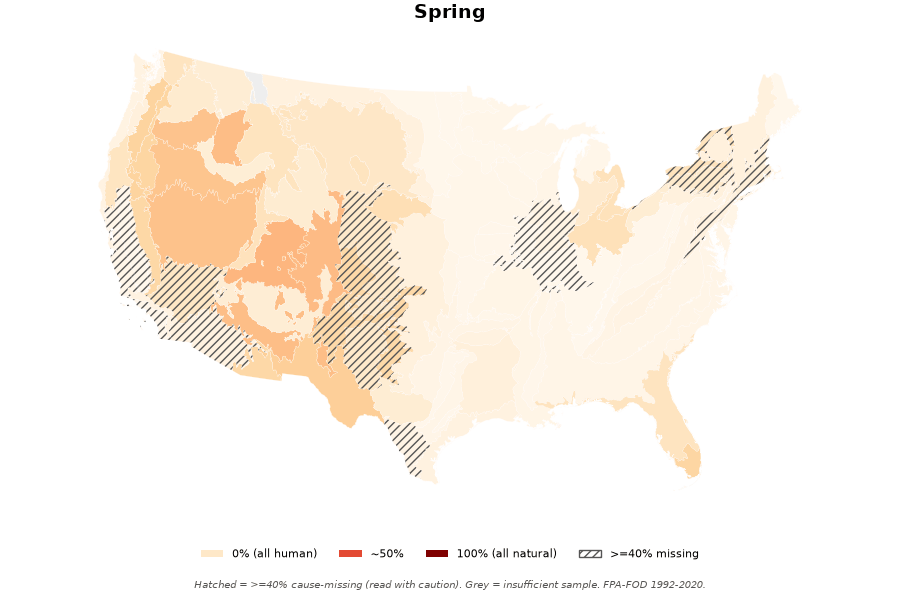

In [10]:
# Animate the hero map (Natural share) into a looping GIF for the talk slide:
# one frame per season, ping-pong so Fall eases back to Winter. Watch the West
# ignite red across summer and cool off -- the season x region interaction.
from IPython.display import Image as IPyImage

SECONDS_PER_SEASON = 2.0   # transition speed -- higher = slower. Try 1.0-3.0.

gif_path = sm.render_natural_share_gif(
    vis_joined, vis_eco, vis_high_miss,
    ms_per_frame=int(SECONDS_PER_SEASON * 1000))
print(f"saved {gif_path.relative_to(sm.ROOT)}")
IPyImage(filename=str(gif_path))

saved img/dominant_acres_seasons.gif


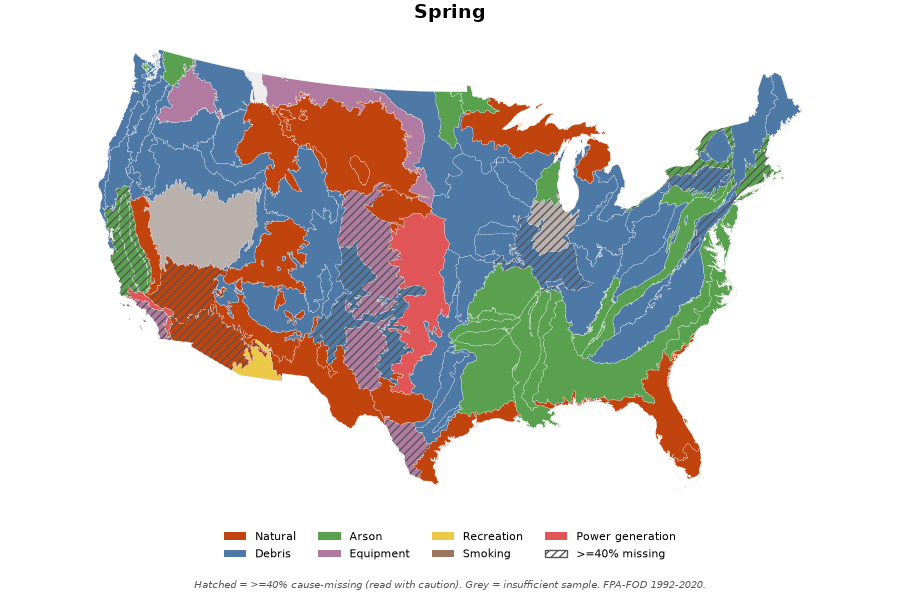

In [13]:
# Animate the impact-weighting map: dominant cause by ACRES BURNED, by season.
# Categorical patchwork is harder to track than a colour ramp, so it defaults
# slower. Regions recolour as the burn-leader shifts -- the moving version of
# the count-vs-burn finding.
ACRES_SECONDS_PER_SEASON = 2.0   # slower than the hero map; try 2.0-3.5.

acres_gif = sm.render_gif(
    vis_joined, vis_eco, vis_high_miss, encoding="dominant_acres",
    ms_per_frame=int(ACRES_SECONDS_PER_SEASON * 1000))
print(f"saved {acres_gif.relative_to(sm.ROOT)}")
IPyImage(filename=str(acres_gif))

saved img/burn_concentration.png | top 1% of fires = 87.5% of acres (this seeded 400K sample)
saved img/slide1_question.png, img/provenance_card.png


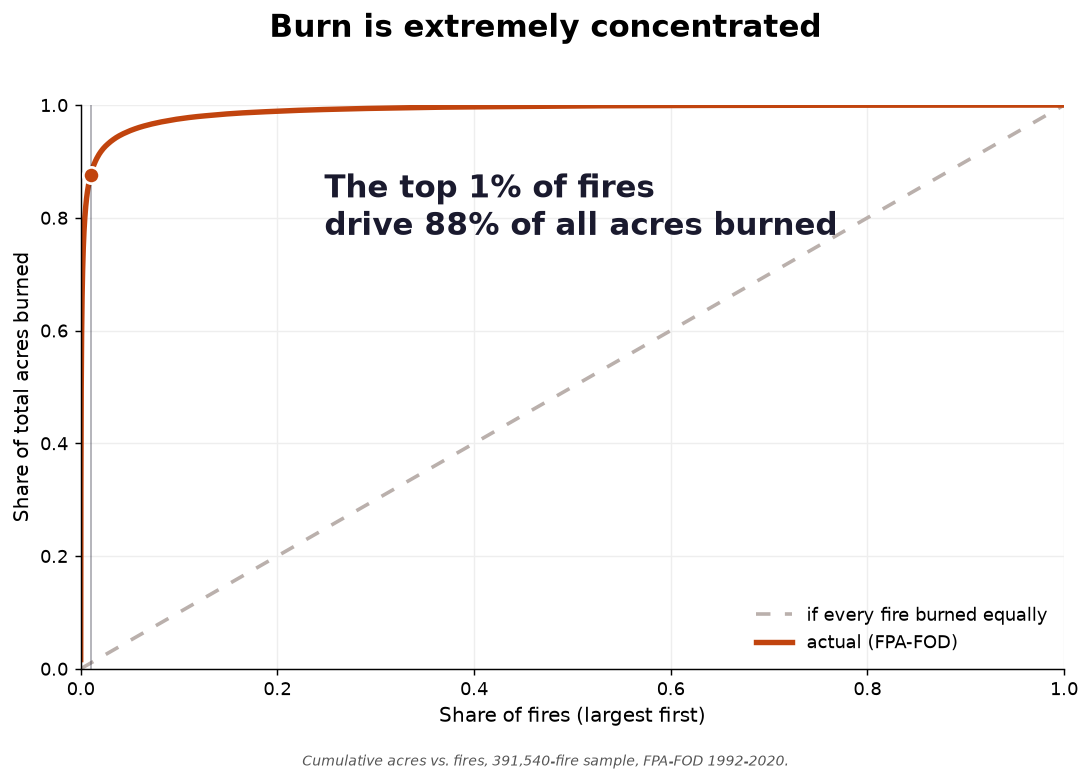

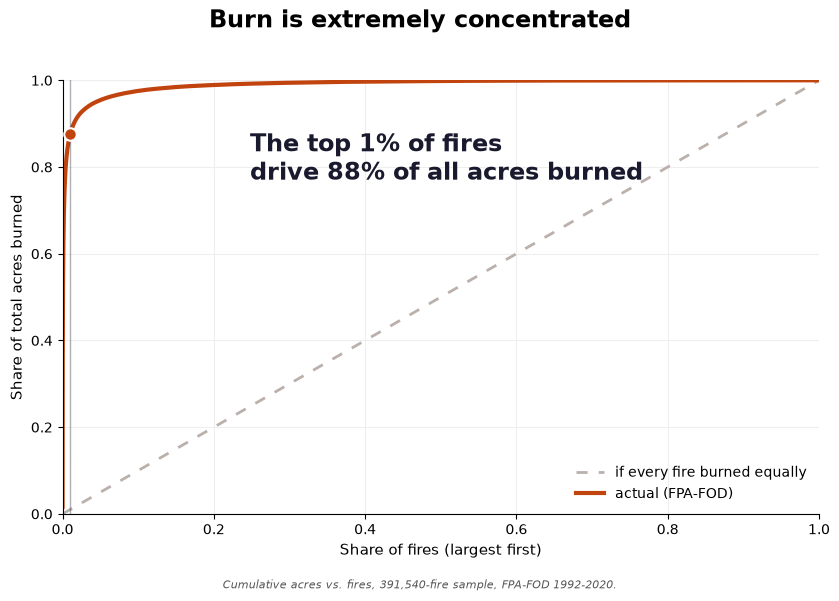

In [12]:
# Remaining slide visuals: the burn-concentration chart (Slide 3 "so-what"),
# and two text cards (Slide 1 question, provenance). All saved to img/.
burn_png, burn_share = sm.render_burn_concentration(vis_joined)
print(f"saved img/{burn_png.name} | top 1% of fires = {burn_share:.1%} of acres "
      f"(this seeded 400K sample)")

sm.render_text_card(
    ["Which wildfire causes drive the most burned area",
     "across U.S. region-seasons — and do the patterns",
     "differ enough to target prevention differently?"],
    "slide1_question.png",
    subtitle="FPA-FOD · 2.3M U.S. wildfires · 1992–2020")

sm.render_text_card(
    ["USDA Forest Service · FPA-FOD, 6th ed. (Short 2022)",
     "2.3 million wildfires · 1992–2020",
     "cause · location · date · size on every record"],
    "provenance_card.png")
print("saved img/slide1_question.png, img/provenance_card.png")
IPyImage(filename=str(burn_png))